   hour  score
0  7.33     73
1  3.71     55
2  3.43     55
3  3.06     89
4  3.33     79
[[ 7.33 73.  ]
 [ 3.71 55.  ]
 [ 3.43 55.  ]
 [ 3.06 89.  ]
 [ 3.33 79.  ]]


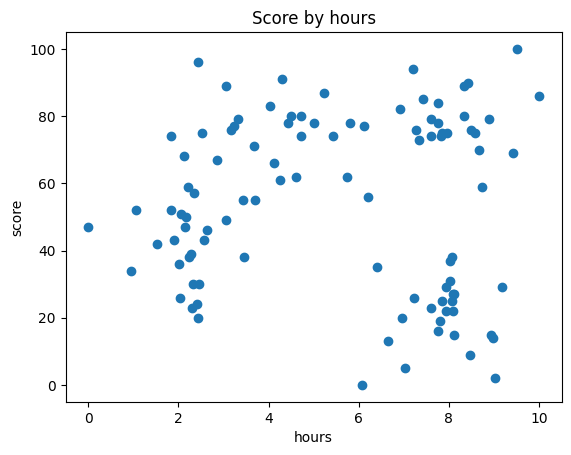

In [3]:
import os
os.environ['OMP_NUM_THREADS'] ='1'
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

dataset = pd.read_csv('./dataset/KMeansData.csv')
print(dataset.head())

X = dataset.iloc[:,:].values
print(X[:5])

plt.scatter(X[:,0], X[:, 1])
plt.title('Score by hours')
plt.xlabel('hours')
plt.ylabel('score')
plt.show()

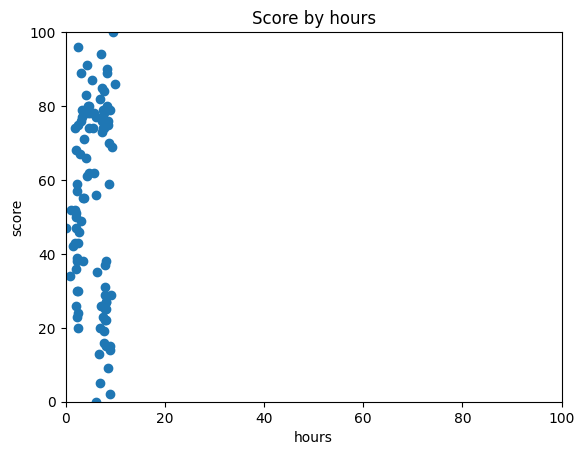

In [4]:
plt.scatter(X[:,0], X[:, 1])
plt.title('Score by hours')
plt.xlabel('hours')
plt.xlim(0, 100)
plt.ylabel('score')
plt.ylim(0, 100)
plt.show()

[[ 0.68729921  0.73538376]
 [-0.66687438  0.04198891]
 [-0.77161709  0.04198891]
 [-0.9100271   1.35173473]
 [-0.8090252   0.96651537]]


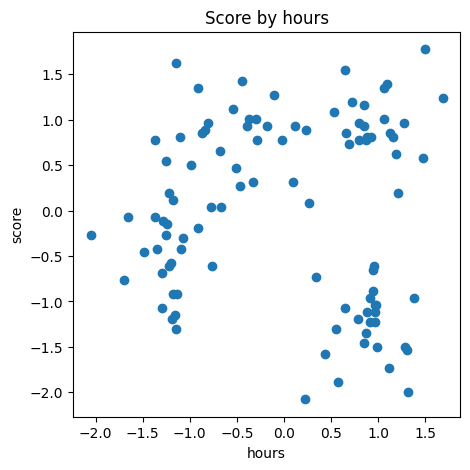

In [6]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X = sc.fit_transform(X)
print(X[:5])

plt.figure(figsize =(5, 5))
plt.scatter(X[:,0], X[:, 1])
plt.title('Score by hours')
plt.xlabel('hours')
plt.ylabel('score')
plt.show()

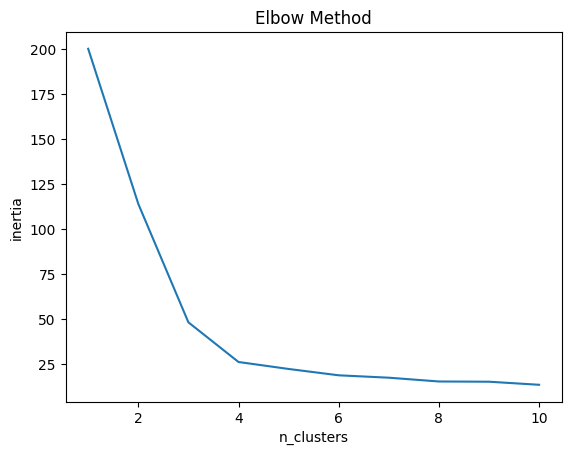

In [7]:
from sklearn.cluster import KMeans
inertia_list = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=0)
    kmeans.fit(X)
    inertia_list.append(kmeans.inertia_)
plt.plot(range(1, 11), inertia_list)
plt.title('Elbow Method')
plt.xlabel('n_clusters')
plt.ylabel('inertia')
plt.show()

[1 0 3 0 0 2 2 0 1 0 0 3 2 3 3 0 2 1 3 0 2 0 3 2 1 1 3 3 3 3 2 2 3 0 1 1 3
 0 0 0 3 2 1 3 3 1 2 0 2 2 1 0 2 2 0 0 0 0 3 2 2 1 1 1 1 2 2 0 2 1 3 1 1 1
 3 3 3 3 0 1 2 1 2 2 1 0 3 2 1 3 0 2 0 1 3 0 1 0 2 3]
[[-0.54299598  0.79316666]
 [ 0.96910697  0.97133061]
 [ 0.8837666  -1.26929779]
 [-1.24939347 -0.48807293]]


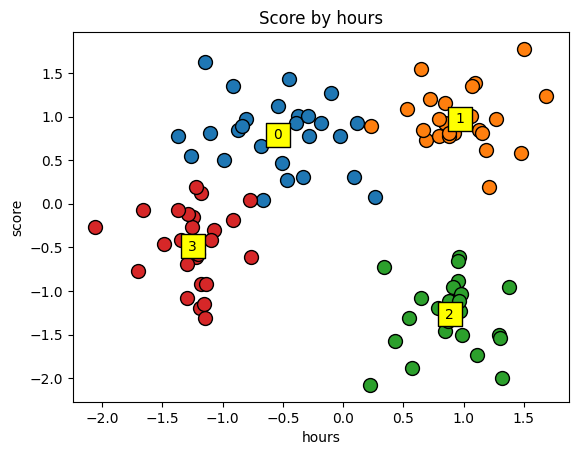

In [8]:
K=4
kmeans = KMeans(n_clusters=K, random_state=0)
y_kmeans = kmeans.fit_predict(X)

print(y_kmeans)

centers = kmeans.cluster_centers_
print(centers)

for cluster in range(K):
    plt.scatter(X[y_kmeans == cluster, 0], X[y_kmeans == cluster, 1], s=100, edgecolor='black')
    plt.scatter(centers[cluster, 0], centers[cluster, 1], s=300, edgecolor='black', color='yellow', marker='s')
    plt.text(centers[cluster, 0], centers[cluster, 1], cluster, va='center', ha='center')

plt.title('Score by hours')
plt.xlabel('hours')
plt.ylabel('score')
plt.show()

[[ 0.68729921  0.73538376]
 [-0.66687438  0.04198891]
 [-0.77161709  0.04198891]
 [-0.9100271   1.35173473]
 [-0.8090252   0.96651537]]
[[-0.54299598  0.79316666]
 [ 0.96910697  0.97133061]
 [ 0.8837666  -1.26929779]
 [-1.24939347 -0.48807293]]


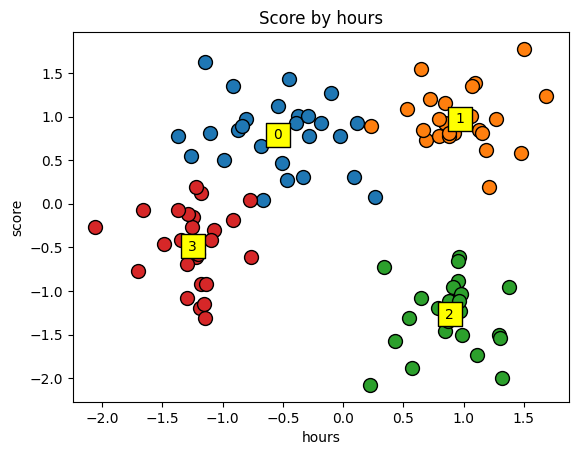

In [9]:
X_org = sc.inverse_transform(X)
print(X_org[:5])

centers_org = sc.inverse_transform(centers)
print(centers_org)

for cluster in range(K):
    plt.scatter(X_org[y_kmeans == cluster, 0], X_org[y_kmeans == cluster, 1], s=100, edgecolor='black')
    plt.scatter(centers_org[cluster, 0], centers_org[cluster, 1], s=300, edgecolor='black', color='yellow', marker='s')
    plt.text(centers_org[cluster, 0], centers_org[cluster, 1], cluster, va='center', ha='center')

plt.title('Score by hours')
plt.xlabel('hours')
plt.ylabel('score')
plt.show()